# Cross-venue funding-rate arbitrage in perpetual futures

**Question:** funding rates for the same perpetual contract differ across
venues. Is the differential large and persistent enough to harvest with a
delta-neutral two-leg position, after realistic costs?

**Approach:** pull public funding-rate history for BTC and ETH perps from
three tier-1 CEXes (Binance, Bybit, OKX) and one newer on-chain venue
(Hyperliquid), quantify the cross-venue spreads, then backtest two
implementations — a fast spread-following rotation and a slow structural
carry — with explicit fee and slippage assumptions.

**Why I care:** I run a live two-leg funding-arbitrage book (different venue
pair, venue-agnostic leg abstraction). This notebook reproduces the research
workflow on fully public data — none of the parameters here are the ones I
trade.

**Findings (all derived below; 180 days of history, 93 where OKX caps it):**
1. Between tier-1 CEXes the spread is economically dead: means under ~2%
   annualized, epoch-level noise with a half-life of a few hours. Whatever
   edge existed there has been arbitraged out.
2. The newer venue trades at a **structural funding premium** to Binance
   (≈2% annualized on BTC, ≈3–5% on ETH, sign-stable across both halves of
   the sample) — consistent with one-sided long demand and capital that is
   slower to bridge to new venues.
3. A fast rotation rule loses money on *every* pair, including the one with
   the largest spread: at 8-hour granularity the spread's noise component is
   unforecastable, and chasing it pays four taker legs per flip.
4. A slow rule that only harvests the structural mean (orient from a trailing
   30-day mean, wide hysteresis, a handful of transitions in six months)
   keeps most of the gross carry on the structural pair. The residual edge on majors is modest — which is the honest
   conclusion, and is why my live book targets newer venues and a wider
   symbol set, where the same structure is larger.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

DATA = Path("../data")
DAYS = 180
END_MS = int(time.time() * 1000)
START_MS = END_MS - DAYS * 24 * 3600 * 1000
ANN = 3 * 365 * 100  # per-8h rate -> annualized %

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

/Users/nkululeko.kuro/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Data: public funding-rate histories

All four venues publish funding history through unauthenticated endpoints.
The CEXes settle every 8 hours (00:00 / 08:00 / 16:00 UTC); Hyperliquid
settles **hourly**, so its rates are summed into the same right-closed 8-hour
epochs. That schedule mismatch is not a nuisance detail: in a live book it
changes intra-epoch risk and signal construction, and it is one reason naive
cross-venue comparisons mislead.

Fetched data is cached under `../data/*.csv`; the notebook falls back to the
cache when offline, so committed outputs are reproducible.

In [2]:
def fetch_binance(symbol: str) -> pd.DataFrame:
    rows, start = [], START_MS
    while True:
        r = requests.get(
            "https://fapi.binance.com/fapi/v1/fundingRate",
            params={"symbol": symbol, "startTime": start, "endTime": END_MS, "limit": 1000},
            timeout=15,
        )
        batch = r.json()
        if not isinstance(batch, list) or not batch:
            break
        rows += [(int(x["fundingTime"]), float(x["fundingRate"])) for x in batch]
        if len(batch) < 1000:
            break
        start = rows[-1][0] + 1
    return pd.DataFrame(rows, columns=["ts", "rate"])


def fetch_bybit(symbol: str) -> pd.DataFrame:
    rows, end = [], END_MS
    while end > START_MS:
        r = requests.get(
            "https://api.bybit.com/v5/market/funding/history",
            params={"category": "linear", "symbol": symbol,
                    "startTime": START_MS, "endTime": end, "limit": 200},
            timeout=15,
        )
        batch = r.json()["result"]["list"]
        if not batch:
            break
        rows += [(int(x["fundingRateTimestamp"]), float(x["fundingRate"])) for x in batch]
        oldest = min(int(x["fundingRateTimestamp"]) for x in batch)
        if len(batch) < 200:
            break
        end = oldest - 1
        time.sleep(0.15)
    return pd.DataFrame(rows, columns=["ts", "rate"])


def fetch_okx(symbol: str) -> pd.DataFrame:
    inst = symbol.replace("USDT", "-USDT-SWAP")
    rows, after = [], END_MS
    while True:
        r = requests.get(
            "https://www.okx.com/api/v5/public/funding-rate-history",
            params={"instId": inst, "after": after, "limit": 100},
            timeout=15,
        )
        batch = r.json()["data"]
        if not batch:
            break
        rows += [(int(x["fundingTime"]), float(x["fundingRate"])) for x in batch]
        oldest = min(int(x["fundingTime"]) for x in batch)
        if oldest <= START_MS:
            break
        after = oldest
        time.sleep(0.15)
    df = pd.DataFrame(rows, columns=["ts", "rate"])
    return df[df.ts >= START_MS]


def fetch_hyperliquid(symbol: str) -> pd.DataFrame:
    coin = symbol.replace("USDT", "")
    rows, start = [], START_MS
    while True:
        r = requests.post(
            "https://api.hyperliquid.xyz/info",
            json={"type": "fundingHistory", "coin": coin,
                  "startTime": start, "endTime": END_MS},
            timeout=15,
        )
        batch = r.json()
        if not batch:
            break
        rows += [(int(x["time"]), float(x["fundingRate"])) for x in batch]
        if len(batch) < 500:
            break
        start = rows[-1][0] + 1
        time.sleep(0.1)
    return pd.DataFrame(rows, columns=["ts", "rate"])


FETCHERS = {
    "binance": fetch_binance,
    "bybit": fetch_bybit,
    "okx": fetch_okx,
    "hyperliquid": fetch_hyperliquid,
}


def load_funding(venue: str, symbol: str) -> pd.Series:
    """Fetch live and cache; fall back to the committed cache offline.
    Returns one observation per 8h epoch (right-closed), as a fraction."""
    path = DATA / f"funding_{venue}_{symbol}.csv"
    try:
        df = FETCHERS[venue](symbol)
        assert len(df) > 0
        df.to_csv(path, index=False)
    except Exception as exc:
        print(f"{venue}/{symbol}: live fetch failed ({exc!r}), using cache")
        df = pd.read_csv(path)
    idx = pd.to_datetime(df.ts, unit="ms", utc=True).dt.round("60min")
    s = pd.Series(df.rate.values, index=idx, name=venue).sort_index()
    s = s[~s.index.duplicated(keep="last")]
    if venue == "hyperliquid":  # hourly settlement -> sum into complete 8h epochs
        agg = s.resample("8h", closed="right", label="right", origin="epoch").agg(["sum", "count"])
        s = agg["sum"][agg["count"] == 8].rename(venue)
    return s


def load_panel(symbol: str) -> pd.DataFrame:
    return pd.concat([load_funding(v, symbol) for v in FETCHERS], axis=1)


def pair_spread(p: pd.DataFrame, a: str, b: str) -> pd.Series:
    """Per-pair join: venues have different history depth."""
    return (p[a] - p[b]).dropna()


panels = {sym: load_panel(sym) for sym in ("BTCUSDT", "ETHUSDT")}
for sym, p in panels.items():
    depth = ", ".join(f"{v}: {p[v].notna().sum()}" for v in p.columns)
    print(f"{sym} 8h epochs per venue — {depth}")

BTCUSDT 8h epochs per venue — binance: 540, bybit: 540, okx: 279, hyperliquid: 539
ETHUSDT 8h epochs per venue — binance: 540, bybit: 540, okx: 279, hyperliquid: 539


## 2. Funding levels and cross-venue spreads

Everything is annualized (`8h rate × 3 × 365`, in %). The 7-day rolling mean
strips epoch noise and shows the regimes that matter for carry.

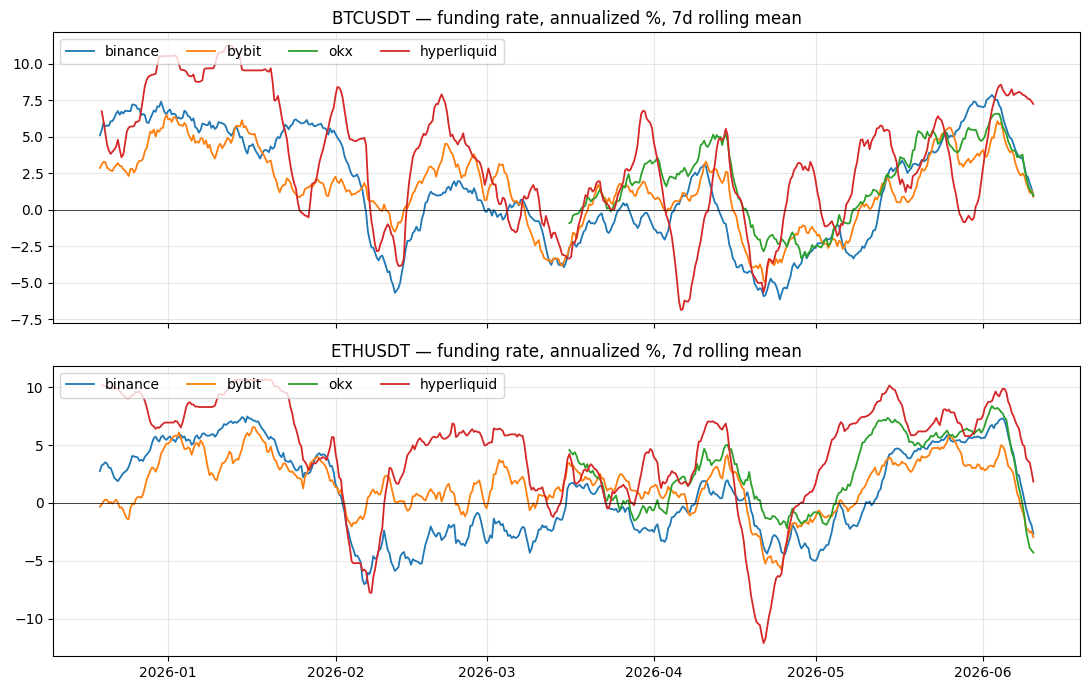

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, (sym, p) in zip(axes, panels.items()):
    smooth = (p * ANN).rolling(21).mean()  # 21 epochs = 7 days
    for venue in p.columns:
        ax.plot(smooth.index, smooth[venue], label=venue, lw=1.3)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{sym} — funding rate, annualized %, 7d rolling mean")
    ax.legend(loc="upper left", ncol=4)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
PAIRS = [("binance", "bybit"), ("binance", "okx"), ("bybit", "okx"),
         ("hyperliquid", "binance")]

def spread_stats(p: pd.DataFrame) -> pd.DataFrame:
    out = {}
    for a, b in PAIRS:
        s = pair_spread(p, a, b) * ANN
        h1, h2 = s.iloc[: len(s) // 2], s.iloc[len(s) // 2:]
        rho = s.autocorr(1)
        out[f"{a}-{b}"] = {
            "days": len(s) / 3,
            "mean (ann %)": s.mean(),
            "1st half mean": h1.mean(),
            "2nd half mean": h2.mean(),
            "mean |spread|": s.abs().mean(),
            "std": s.std(),
            "AR(1)": rho,
            "half-life (h)": 8 * np.log(0.5) / np.log(rho) if 0 < rho < 1 else np.nan,
        }
    return pd.DataFrame(out).T

pd.concat({sym: spread_stats(p) for sym, p in panels.items()})

days  mean (ann %)  1st half mean  \
BTCUSDT binance-bybit       180.000         0.018          0.479   
        binance-okx          93.000        -1.476         -2.775   
        bybit-okx            93.000        -1.024         -1.415   
        hyperliquid-binance 179.667         1.862          1.981   
ETHUSDT binance-bybit       180.000        -0.674         -0.868   
        binance-okx          93.000        -1.815         -1.981   
        bybit-okx            93.000        -1.274         -0.832   
        hyperliquid-binance 179.667         3.755          4.606   

                             2nd half mean  mean |spread|   std  AR(1)  \
BTCUSDT binance-bybit               -0.443          3.948 5.117  0.383   
        binance-okx                 -0.187          3.763 4.659  0.267   
        bybit-okx                   -0.636          3.985 4.905  0.204   
        hyperliquid-binance          1.744          6.198 7.615  0.578   
ETHUSDT binance-bybit               -0.481          4.257 5.543  0.415   
        binance-okx                 -1.650          4.272 5.482  0.319   
        bybit-okx                   -1.713          5.249 6.560  0.259   
        hyperliquid-binance          2.907          6.464 7.224  0.587   

                             half-life (h)  
BTCUSDT binance-bybit                5.778  
        binance-okx                  4.196  
        bybit-okx                    3.483  
        hyperliquid-binance         10.108  
ETHUSDT binance-bybit                6.298  
        binance-okx                  4.848  
        bybit-okx                    4.100  
        hyperliquid-binance         10.415

Two different objects are hiding in this table:

- **CEX–CEX pairs:** means mostly within ±2% annualized, dwarfed by a noise
  component whose half-life is a few hours. There is no carry to collect and
  nothing forecastable at the 8-hour horizon.
- **hyperliquid–binance:** a positive mean spread — the newer venue pays its
  longs' funding premium — that has the **same sign in both halves** of the
  sample on both symbols. That is a structural object, not noise: perp DEX
  open interest skews long, and the capital that would compress the premium
  must bridge, manage on-chain account risk, and accept venue risk to do so.

The decomposition dictates the strategy design: the noise is untradeable
(see below), the structural mean is the product.

## 3. Costs, stated explicitly

Position: short the perp where funding is higher (receive), long the same
notional where it is lower (pay less). Delta nets to ~zero; the position
earns the spread. Decisions are made once per epoch on **previous** epochs
only.

| item | assumption |
|---|---|
| taker fee | 3.0 bps per leg |
| slippage + spread crossing | 2.0 bps per leg |
| enter or exit a pair | 2 legs → 10 bps of notional |
| flip orientation | 4 legs → 20 bps of notional |

## 4. Strategy A: fast spread-following rotation (the naive idea)

Follow a ~1-week EMA of the spread: enter when |EMA| > 3% annualized, exit
below 1%, flip on a sign change beyond the entry threshold. This is what
"trade the spread" usually means on first attempt.

In [5]:
LEG_COST = (3.0 + 2.0) / 1e4  # fee + slippage per leg, fraction of notional

def run(spread_8h: pd.Series, signal_ann: pd.Series, entry: float, exit_: float,
        costs: bool = True):
    """Shared engine: signal_ann must already be shifted (no lookahead)."""
    pos, pnl, transitions = 0, [], 0
    for sig, sp in zip(signal_ann, spread_8h):
        target = pos
        if not np.isnan(sig):
            if pos == 0 and abs(sig) > entry:
                target = int(np.sign(sig))
            elif pos != 0 and abs(sig) < exit_:
                target = 0
            elif pos != 0 and np.sign(sig) != pos and abs(sig) > entry:
                target = -pos
        cost = 0.0
        if costs and target != pos:
            cost = (2 if (pos == 0 or target == 0) else 4) * LEG_COST
            transitions += 1
        pos = target
        pnl.append(pos * sp - cost)
    return pd.Series(pnl, index=spread_8h.index), transitions


def summarize(pnl: pd.Series, transitions: int) -> dict:
    years = len(pnl) / (3 * 365)
    cum = pnl.cumsum()
    return {
        "net pnl (% notional)": 100 * pnl.sum(),
        "ann. net (%)": 100 * pnl.sum() / years,
        "max DD (%)": 100 * (cum - cum.cummax()).min(),
        "transitions": transitions,
        "% time in position": 100 * (pnl != 0).mean(),
    }


fast = {}
for sym, p in panels.items():
    for a, b in PAIRS:
        spread = pair_spread(p, a, b)
        ema = (spread.ewm(span=21).mean() * ANN).shift(1)
        pnl, n = run(spread, ema, entry=3.0, exit_=1.0)
        fast[(sym, f"{a}-{b}")] = summarize(pnl, n)
pd.DataFrame(fast).T

net pnl (% notional)  ann. net (%)  max DD (%)  \
BTCUSDT binance-bybit                      -1.934        -3.921      -1.934   
        binance-okx                        -0.579        -2.272      -0.579   
        bybit-okx                          -0.567        -2.225      -0.567   
        hyperliquid-binance                -2.486        -5.050      -2.561   
ETHUSDT binance-bybit                      -0.940        -1.906      -0.998   
        binance-okx                        -0.947        -3.718      -0.947   
        bybit-okx                          -1.268        -4.975      -1.268   
        hyperliquid-binance                -0.684        -1.390      -0.890   

                             transitions  % time in position  
BTCUSDT binance-bybit             22.000              40.000  
        binance-okx                8.000              39.785  
        bybit-okx                  6.000              19.355  
        hyperliquid-binance       33.000              63.636  
ETHUSDT binance-bybit             16.000              55.741  
        binance-okx               12.000              52.688  
        bybit-okx                 14.000              41.219  
        hyperliquid-binance       23.000              78.108

**Strategy A loses on every pair** — including hyperliquid–binance, the pair
with the largest spread. The mechanism is worth being precise about: the EMA
mostly tracks the noise component, whose half-life (hours) is far shorter
than the EMA's reaction time, so the rule systematically enters after spikes
that have already reverted, and every wrong flip costs four taker legs. A
better filter doesn't fix this; at 8-hour granularity there is nothing there
to forecast.

## 5. Strategy B: slow structural carry

If the harvestable object is the structural mean, the rule should barely
trade: orient from a trailing **30-day mean** of the spread, require it to
clear 1.5% annualized, exit only if it decays below 0.5%. Expected behaviour:
one entry, near-zero turnover thereafter.

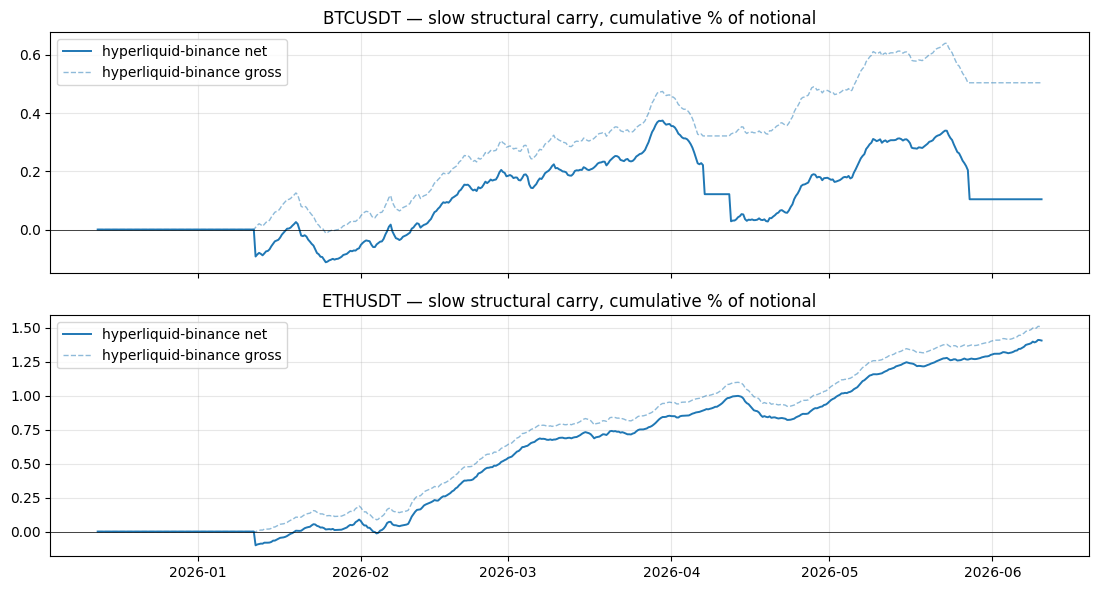

net pnl (% notional)  ann. net (%)  max DD (%)  \
BTCUSDT binance-bybit                      -0.289        -0.587      -0.343   
        binance-okx                         0.025         0.098      -0.137   
        bybit-okx                          -0.236        -0.927      -0.251   
        hyperliquid-binance                 0.104         0.211      -0.347   
ETHUSDT binance-bybit                      -0.065        -0.131      -0.313   
        binance-okx                         0.119         0.467      -0.134   
        bybit-okx                           0.120         0.469      -0.109   
        hyperliquid-binance                 1.407         2.858      -0.177   

                             transitions  % time in position  
BTCUSDT binance-bybit              5.000              67.222  
        binance-okx                2.000              53.047  
        bybit-okx                  3.000              52.688  
        hyperliquid-binance        4.000              73.098  
ETHUSDT binance-bybit              5.000              60.000  
        binance-okx                2.000              65.591  
        bybit-okx                  1.000              49.821  
        hyperliquid-binance        1.000              82.560

In [6]:
slow = {}
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, (sym, p) in zip(axes, panels.items()):
    for a, b in PAIRS:
        spread = pair_spread(p, a, b)
        trailing = (spread.rolling(90).mean() * ANN).shift(1)  # 90 epochs = 30d
        pnl, n = run(spread, trailing, entry=1.5, exit_=0.5)
        slow[(sym, f"{a}-{b}")] = summarize(pnl, n)
        if (a, b) == ("hyperliquid", "binance"):
            ax.plot(pnl.index, 100 * pnl.cumsum(), lw=1.4,
                    label=f"{a}-{b} net", color="tab:blue")
            gross, _ = run(spread, trailing, entry=1.5, exit_=0.5, costs=False)
            ax.plot(gross.index, 100 * gross.cumsum(), lw=1.0, ls="--",
                    label=f"{a}-{b} gross", color="tab:blue", alpha=0.5)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{sym} — slow structural carry, cumulative % of notional")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

pd.DataFrame(slow).T

The slow rule is flat-to-marginally-negative on the CEX pairs — it mostly
refuses to trade dead spreads, and what little it loses is churn from means
hovering near the threshold. On hyperliquid–binance it is positive on both
symbols, and on ETH it does exactly what it was designed to do: **one entry,
~83% of the sample in position, +1.4% of notional over six months (~2.9%
annualized)** against a gross structural mean of ~3.8% — the gap being the
30-day burn-in and the entry cost paid once.

**On capital rather than notional:** both legs consume margin. At 5× on each
venue with a 2× liquidation buffer, capital ≈ 0.8 × notional, so multiply the
notional figures by ~1.25 — still single-digit annualized on majors. That is
the honest number, and it is why the live version of this trade goes where
the premium is larger: newer venues, hourly-funding schedules, and a wider
symbol set beyond BTC/ETH.

## 6. What the clean backtest hides

The public-data version above ignores everything that actually consumes
engineering time in my live two-leg book:

- **Legging risk.** The two legs do not fill atomically. A size cap or nonce
  contention on one venue can fill half of one leg and leave you net-long in
  a moving market. The live system treats the *pair* as the unit of
  execution: cap-aware sizing before submission, then reconcile-and-repair
  rather than fire-and-forget.
- **Venue outages.** When one venue is down you can neither enter nor safely
  exit. The live playbook skips the rebalance tick entirely rather than
  retrying into a half-alive venue.
- **Mark-price basis.** The two perps' marks diverge intraday; carry is
  earned in funding but equity breathes with the basis, which matters for
  margin, liquidation distance and risk limits.
- **Venue risk is a position.** Capital parked on the weaker venue of the
  pair *is* exposure to that venue. This caps size long before market impact
  does — and it is the flip side of why the premium exists at all.

## 7. Conclusions

1. Funding arbitrage between tier-1 CEXes on majors is gone; the table in
   §2 is what an arbitraged-out spread looks like.
2. The live edge is structural, not statistical: a sign-stable premium on
   newer venues, harvested by a rule designed to *not* trade. Strategy
   design followed the decomposition of the spread, not the other way
   around.
3. The fast version of the trade is a money-losing machine even at zero
   edge-threshold tuning — worth showing precisely because rejecting
   implementations is most of what research is for.
4. What keeps the remaining edge alive is operational: atomic-ish legging,
   reconciliation, outage handling, margin management across venues. That
   work doesn't show up in public data, which is exactly why it still pays.